# 1. Setup & Environment

Phần này khởi tạo môi trường, cài đặt thư viện và định nghĩa các hàm hỗ trợ trực quan hóa (Visualization).

## 1.1. Cài đặt và Import thư viện

In [1]:
!pip install mediapipe
!wget -q https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.6 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.


In [2]:
!pip list | grep mediapipe

mediapipe                                0.10.32


In [3]:
import os
import cv2
import time
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# MediaPipe & Tasks API
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
# from mediapipe.framework.formats import landmark_pb2

# Deep Learning (TensorFlow/Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Sklearn Metrics & Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Config hiển thị
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

2026-02-06 07:39:20.664211: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770363561.010404      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770363561.120545      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770363562.009348      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770363562.009388      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770363562.009391      24 computation_placer.cc:177] computation placer alr

## 1.2. Định nghĩa hàm vẽ Landmarks (Custom)

Hàm này giúp vẽ các khớp tay với màu sắc riêng biệt cho từng ngón để dễ quan sát.

In [4]:
def to_pixel(x_norm: float, y_norm: float, w: int, h: int) -> tuple[int, int]:
    x = min(max(x_norm, 0.0), 1.0)
    y = min(max(y_norm, 0.0), 1.0)
    return int(x * w), int(y * h)

def draw_landmarks_on_image_new(rgb_image, detection_result):
    """Vẽ landmarks với màu sắc riêng cho từng ngón tay."""
    hand_landmarks_list = detection_result.hand_landmarks
    annotated_image = np.copy(rgb_image)
    h, w = annotated_image.shape[:2]

    # Định nghĩa các đốt ngón tay
    fingers_connections = {
        "thumb":  [(0, 1), (1, 2), (2, 3), (3, 4)],
        "index":  [(0, 5), (5, 6), (6, 7), (7, 8)],
        "middle": [(0, 9), (9, 10), (10, 11), (11, 12)],
        "ring":   [(0, 13), (13, 14), (14, 15), (15, 16)],
        "pinky":  [(0, 17), (17, 18), (18, 19), (19, 20)]
    }

    # Màu sắc (RGB)
    finger_colors = {
        "thumb":  (255, 0, 0),    # Đỏ
        "index":  (0, 255, 0),    # Xanh lá
        "middle": (0, 0, 255),    # Xanh dương
        "ring":   (255, 255, 0),  # Vàng
        "pinky":  (255, 0, 255)   # Tím
    }

    if hand_landmarks_list:
        for hand_landmarks in hand_landmarks_list:
            pts = [to_pixel(lm.x, lm.y, w, h) for lm in hand_landmarks]
            
            # Vẽ đường nối
            for finger, connections in fingers_connections.items():
                color = finger_colors[finger]
                for idx_a, idx_b in connections:
                    cv2.line(annotated_image, pts[idx_a], pts[idx_b], color, 2)
            
            # Vẽ điểm khớp
            for (x, y) in pts:
                cv2.circle(annotated_image, (x, y), 3, (255, 255, 255), -1)
                cv2.circle(annotated_image, (x, y), 4, (0, 0, 0), 1)

    return annotated_image

# 2. Data Processing

## 2.0. KHAI THÁC VÀ TỔNG HỢP DỮ LIỆU ĐA NGUỒN

Chúng ta sẽ sử dụng 4 nguồn dữ liệu sau:

    asl-dataset

    asl-alphabet-dataset

    hand-signs-asl-hand-sign-data

    synthetic-asl-alphabet

Mục tiêu là tạo ra 2 thư mục thống nhất tại /kaggle/working/:

    ASL_TOTAL_TRAIN: Chứa toàn bộ ảnh huấn luyện của tất cả các nguồn, phân theo folder (A, B, C...).

    ASL_TOTAL_TEST: Chứa toàn bộ ảnh kiểm thử có nhãn.

### 2.0.1: Khám phá cấu trúc thư mục gốc

Cell này giúp in ra cấu trúc cây thư mục để biết chính xác đường dẫn chứa ảnh (Train/Test) nằm ở đâu trong các dataset đầu vào.

In [5]:
import os

# Danh sách các dataset đầu vào
INPUT_ROOTS = [
    '/kaggle/input/asl-dataset/asl_dataset',
    '/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset',
    '/kaggle/input/hand-signs-asl-hand-sign-data/DATASET',
    '/kaggle/input/synthetic-asl-alphabet/Test_Alphabet', # Lưu ý: Đây chỉ là folder Test, cần check folder cha để lấy Train
    '/kaggle/input/synthetic-asl-alphabet/Train_Alphabet' # Thêm đường dẫn Train của bộ Synthetic
]

print("--- KHÁM PHÁ CẤU TRÚC DỮ LIỆU ---")

def list_dirs_only(path, depth=1):
    if depth < 0: return
    try:
        if os.path.isdir(path):
            subdirs = sorted([d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))])
            # Chỉ in nếu folder chứa ít hơn 50 folder con (để tránh in hết A-Z làm rối màn hình)
            if len(subdirs) > 0:
                print(f"{path}")
                if len(subdirs) > 10:
                    print(f"   ├── Gồm {len(subdirs)} thư mục con: {subdirs[:5]} ... {subdirs[-5:]}")
                else:
                    print(f"   ├── {subdirs}")
                
                # Đệ quy
                for d in subdirs:
                    # Chỉ đi sâu vào các folder chính, không đi vào từng folder chữ cái
                    if d.lower() in ['train', 'test', 'dataset', 'asl_alphabet_train', 'asl_alphabet_test', 'asl_dataset']:
                        list_dirs_only(os.path.join(path, d), depth-1)
    except Exception as e:
        print(f"Lỗi truy cập {path}: {e}")

# Kiểm tra thư mục gốc của Kaggle input
print("ROOT: /kaggle/input")
for item in os.listdir("/kaggle/input"):
    full_path = os.path.join("/kaggle/input", item)
    list_dirs_only(full_path, depth=2)

--- KHÁM PHÁ CẤU TRÚC DỮ LIỆU ---
ROOT: /kaggle/input
/kaggle/input/aslamerican-sign-language-aplhabet-dataset
   ├── ['ASL_Alphabet_Dataset']
/kaggle/input/hand-signs-asl-hand-sign-data
   ├── ['DATASET']
/kaggle/input/hand-signs-asl-hand-sign-data/DATASET
   ├── Gồm 36 thư mục con: ['0', '1', '2', '3', '4'] ... ['V', 'W', 'X', 'Y', 'Z']
/kaggle/input/asl-dataset
   ├── ['asl_dataset']
/kaggle/input/asl-dataset/asl_dataset
   ├── Gồm 37 thư mục con: ['0', '1', '2', '3', '4'] ... ['v', 'w', 'x', 'y', 'z']
/kaggle/input/asl-dataset/asl_dataset/asl_dataset
   ├── Gồm 36 thư mục con: ['0', '1', '2', '3', '4'] ... ['v', 'w', 'x', 'y', 'z']
/kaggle/input/synthetic-asl-alphabet
   ├── ['Test_Alphabet', 'Train_Alphabet']


### 2.0.2: Tạo ASL_TOTAL_TRAIN và ASL_TOTAL_TEST (Sử dụng Symlink)

Cell này thực hiện logic quan trọng: Map các folder từ nguồn vào đích chung. Tôi đã chuẩn hóa tên nhãn (ví dụ đưa hết về chữ in hoa).

In [6]:
import shutil
import random

# 1. Định nghĩa đường dẫn đích
TOTAL_TRAIN_DIR = '/kaggle/working/ASL_TOTAL_TRAIN'
TOTAL_TEST_DIR = '/kaggle/working/ASL_TOTAL_TEST'

# Xóa nếu đã tồn tại để làm mới
if os.path.exists(TOTAL_TRAIN_DIR): shutil.rmtree(TOTAL_TRAIN_DIR)
if os.path.exists(TOTAL_TEST_DIR): shutil.rmtree(TOTAL_TEST_DIR)

os.makedirs(TOTAL_TRAIN_DIR)
os.makedirs(TOTAL_TEST_DIR)

print("Đã tạo thư mục chứa: ", TOTAL_TRAIN_DIR, " và ", TOTAL_TEST_DIR)

# 2. Cấu hình Mapping
# Format: (Đường dẫn nguồn, Loại mặc định, Tỉ lệ chia Test cho số)
DATA_SOURCES = [
    # Nguồn 1: ASL Alphabet Dataset (Chỉ dùng Train)
    ('/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train', 'TRAIN', 0.0),
    ('/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test', 'TEST', 0.0),
    # Nguồn 2: ASL Dataset (Ảnh thực tế, bao gồm 0-9 và a-z)
    # Cần chia sẻ một phần số 0-9 sang tập Test
    ('/kaggle/input/asl-dataset/asl_dataset/asl_dataset', 'TRAIN', 0.2), 

    # Nguồn 3: Hand Signs (Bao gồm 0-9 và A-Z)
    # Đường dẫn sửa lại: Trỏ thẳng vào DATASET
    ('/kaggle/input/hand-signs-asl-hand-sign-data/DATASET', 'TRAIN', 0.2),

    # Nguồn 4: Synthetic ASL (Chỉ dùng Train)
    ('/kaggle/input/synthetic-asl-alphabet/Train_Alphabet', 'TRAIN', 0.0),
    
    # Nguồn 5: Synthetic Test (Đưa thẳng vào Test)
    ('/kaggle/input/synthetic-asl-alphabet/Test_Alphabet', 'TEST', 0.0)
]

def merge_datasets(sources):
    count_link = 0
    
    for src_path, default_type, test_ratio in sources:
        if not os.path.exists(src_path):
            print(f"Cảnh báo: Không tìm thấy đường dẫn {src_path}")
            continue
            
        print(f"Đang xử lý nguồn: {src_path}")
        
        # Duyệt qua từng folder con
        for label_folder in os.listdir(src_path):
            src_label_path = os.path.join(src_path, label_folder)
            
            if os.path.isdir(src_label_path):
                # --- CHUẨN HÓA NHÃN ---
                # Xóa khoảng trắng, đưa về in hoa
                label_std = label_folder.strip().upper()
                
                # Gộp BLANK vào nothing
                if label_std == 'BLANK': label_std = 'nothing'
                if label_std == 'SPACE': label_std = 'space'
                if label_std == 'DEL': label_std = 'del'
                if label_std == 'NOTHING': label_std = 'nothing' # Đảm bảo viết thường thống nhất
                
                # --- LOGIC CHIA DỮ LIỆU TRAIN/TEST ---
                # Mặc định theo cấu hình nguồn
                dest_type = default_type
                
                # Logic đặc biệt: Nếu là số (0-9), trích xuất 1 phần sang Test
                # Vì các bộ Test có sẵn thường thiếu số
                if label_std.isdigit() and test_ratio > 0:
                    # Chúng ta sẽ quyết định từng ảnh bên dưới
                    pass
                elif default_type == 'TEST':
                    pass
                else:
                    dest_type = 'TRAIN'

                # Tạo prefix để tránh trùng tên file
                prefix = os.path.basename(os.path.dirname(src_path))[:5] + "_" 
                
                files = os.listdir(src_label_path)
                for img_name in files:
                    src_file = os.path.join(src_label_path, img_name)
                    
                    # Quyết định file này đi về đâu
                    current_dest_type = dest_type
                    
                    # Nếu là số và nguồn cho phép chia sẻ -> Random chia về Test
                    if label_std.isdigit() and test_ratio > 0:
                        if random.random() < test_ratio:
                            current_dest_type = 'TEST'
                        else:
                            current_dest_type = 'TRAIN'
                    
                    # Tạo đường dẫn đích
                    dest_root = TOTAL_TRAIN_DIR if current_dest_type == 'TRAIN' else TOTAL_TEST_DIR
                    dest_label_path = os.path.join(dest_root, label_std)
                    
                    if not os.path.exists(dest_label_path):
                        os.makedirs(dest_label_path)

                    new_name = f"{prefix}{img_name}"
                    dest_file = os.path.join(dest_label_path, new_name)
                    
                    try:
                        os.symlink(src_file, dest_file)
                        count_link += 1
                    except FileExistsError:
                        pass 
                        
    return count_link

total_links = merge_datasets(DATA_SOURCES)
print(f"\nHOÀN TẤT! Đã tổng hợp {total_links} file ảnh.")

Đã tạo thư mục chứa:  /kaggle/working/ASL_TOTAL_TRAIN  và  /kaggle/working/ASL_TOTAL_TEST
Đang xử lý nguồn: /kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train
Đang xử lý nguồn: /kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_test
Đang xử lý nguồn: /kaggle/input/asl-dataset/asl_dataset/asl_dataset
Đang xử lý nguồn: /kaggle/input/hand-signs-asl-hand-sign-data/DATASET
Đang xử lý nguồn: /kaggle/input/synthetic-asl-alphabet/Train_Alphabet
Đang xử lý nguồn: /kaggle/input/synthetic-asl-alphabet/Test_Alphabet

HOÀN TẤT! Đã tổng hợp 253489 file ảnh.


### 2.0.3: Thống kê tổng hợp dữ liệu mới

Thống kê lại xem sau khi gộp, chúng ta có bao nhiêu ảnh ở mỗi tập.

In [7]:
def summarize_dataset(path, name):
    print(f"\nTHỐNG KÊ TẬP: {name}")
    if not os.path.exists(path):
        print("Chưa tạo thư mục.")
        return

    classes = sorted(os.listdir(path))
    print(f"Số lượng lớp (Classes): {len(classes)}")
    
    total_imgs = 0
    print(f"{'CLASS':<10} | {'SỐ LƯỢNG ẢNH':<15}")
    print("-" * 30)
    
    # Đếm số lượng, hiển thị 5 lớp đầu, 5 lớp cuối và các lớp đặc biệt
    counts = []
    for cls in classes:
        cls_path = os.path.join(path, cls)
        n = len(os.listdir(cls_path))
        counts.append((cls, n))
        total_imgs += n
    
    for cls, n in counts:
        # In ra tất cả hoặc lọc bớt nếu quá dài
        print(f"{cls:<10} | {n:<15}")
        
    print("-" * 30)
    print(f"TỔNG CỘNG: {total_imgs} ảnh")

summarize_dataset(TOTAL_TRAIN_DIR, "ASL_TOTAL_TRAIN")
summarize_dataset(TOTAL_TEST_DIR, "ASL_TOTAL_TEST")


THỐNG KÊ TẬP: ASL_TOTAL_TRAIN
Số lượng lớp (Classes): 39
CLASS      | SỐ LƯỢNG ẢNH   
------------------------------
0          | 81             
1          | 82             
2          | 76             
3          | 75             
4          | 76             
5          | 82             
6          | 74             
7          | 78             
8          | 74             
9          | 81             
A          | 9453           
B          | 9304           
C          | 9141           
D          | 8624           
E          | 8739           
F          | 9026           
G          | 8839           
H          | 8901           
I          | 8948           
J          | 8498           
K          | 8871           
L          | 8934           
M          | 8895           
N          | 8927           
O          | 9135           
P          | 8596           
Q          | 8949           
R          | 9016           
S          | 9104           
T          | 9044           
U          |

## 2.1. Giải thích tham số & Cấu hình

Trước khi xử lý, ta thiết lập các tham số quan trọng cho MediaPipe:

    num_hands = 1: Chỉ định detector tập trung tìm kiếm đúng 1 bàn tay trong khung hình. Giúp giảm nhiễu nền.

    min_hand_detection_confidence = 0.3: Ngưỡng tin cậy thấp (30%) giúp bắt được các bàn tay bị mờ, bị che khuất một phần hoặc ở góc khó trong tập dữ liệu đa dạng.

    Input Vector (42): Dữ liệu đầu vào cho mô hình là vector 1 chiều gồm 42 giá trị thực (21 landmarks × 2 tọa độ x,y).

In [8]:
# Đường dẫn dữ liệu
# DATA_DIR = '/kaggle/input/aslamerican-sign-language-aplhabet-dataset/ASL_Alphabet_Dataset/asl_alphabet_train'
DATA_DIR = '/kaggle/working/ASL_TOTAL_TRAIN'
DATA_PICKLE_PATH = '/kaggle/input/data-pickle/data.pickle'

# Cờ kiểm soát: False = Luôn chạy lại xử lý để kiểm chứng dữ liệu mới
SKIP_PROCESSING = False

## 2.2. Trích xuất đặc trưng (Main Processing)

Đoạn code này thực hiện quét toàn bộ thư mục, detect landmark và lưu lại các mẫu (Sample) để kiểm tra.

In [9]:
from tqdm.notebook import tqdm
import os
import time
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

if not SKIP_PROCESSING:
    print("Dang khoi chay quy trinh xu ly du lieu (Feature Extraction)...")
    
    # Cau hinh MediaPipe Detector
    base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
    options = vision.HandLandmarkerOptions(
        base_options=base_options,
        num_hands=1,
        min_hand_detection_confidence=0.3
    )
    detector = vision.HandLandmarker.create_from_options(options)

    data = []
    labels = []
    
    # List luu mau de visualize
    debug_samples = [] 
    target_viz_indices = np.linspace(0, 3000, 20, dtype=int)
    total_count = 0
    
    # Bien dem tong thoi gian
    global_start = time.time()

    # Lay danh sach cac thu muc class
    # Neu muon chay tat ca cac folder thi bo [:3]
    class_dirs = sorted(os.listdir(DATA_DIR))
    
    # 1. Vong lap qua tung thu muc (Class)
    for dir_ in class_dirs:
        dir_path = os.path.join(DATA_DIR, dir_)
        if not os.path.isdir(dir_path): continue

        # Lay danh sach anh
        all_images = os.listdir(dir_path)
        
        # --- QUAN TRONG: Chi lay 3 anh dau tien cua moi folder ---
        image_files = all_images
        
        # Bat dau do thoi gian cho folder nay
        folder_start_time = time.time()
        folder_count = 0
        
        # 2. Vong lap qua cac file anh (da duoc gioi han so luong)
        for img_path in tqdm(image_files, desc=f"Processing '{dir_}'", leave=False):
            img_full_path = os.path.join(dir_path, img_path)
            
            raw_img = cv2.imread(img_full_path)
            if raw_img is None: continue
            
            img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            
            # Detect Landmark
            detection_result = detector.detect(mp_image)

            if detection_result.hand_landmarks:
                hand_landmarks = detection_result.hand_landmarks[0]
                data_aux = []
                for lm in hand_landmarks:
                    data_aux.append(lm.x)
                    data_aux.append(lm.y)

                if len(data_aux) == 42:
                    data.append(data_aux)
                    labels.append(dir_)
                    folder_count += 1
                    
                    # Luu mau kiem tra
                    if total_count in target_viz_indices or len(debug_samples) < 20:
                        if len(debug_samples) < 20:
                            debug_samples.append({
                                'img_rgb': img_rgb,
                                'result': detection_result,
                                'label': dir_
                            })
                    total_count += 1
        
        # Ket thuc folder: In thong tin thong ke
        folder_time = time.time() - folder_start_time
        print(f"Class '{dir_}': {folder_count}/{len(image_files)} anh hop le | {folder_time:.2f}s")

    detector.close()
    print(f"\nHOAN TAT TOAN BO! Tong mau: {len(data)} | Tong thoi gian: {time.time()-global_start:.2f}s")

else:
    print(f"Bo qua xu ly. Load du lieu tu {DATA_PICKLE_PATH}")
    with open(DATA_PICKLE_PATH, 'rb') as f:
        data_dict = pickle.load(f)
        data = data_dict['data']
        labels = data_dict['labels']

Dang khoi chay quy trinh xu ly du lieu (Feature Extraction)...


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1770363600.888175      85 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770363600.909348      85 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Processing '0':   0%|          | 0/81 [00:00<?, ?it/s]

W0000 00:00:1770363601.014723      84 landmark_projection_calculator.cc:78] Using NORM_RECT without IMAGE_DIMENSIONS is only supported for the square ROI. Provide IMAGE_DIMENSIONS or use PROJECTION_MATRIX.


Class '0': 31/81 anh hop le | 3.13s


...

Class 'del': 4055/6836 anh hop le | 264.32s


Processing 'nothing':   0%|          | 0/3930 [00:00<?, ?it/s]

Class 'nothing': 8/3930 anh hop le | 141.67s


Processing 'space':   0%|          | 0/7071 [00:00<?, ?it/s]

Class 'space': 3747/7071 anh hop le | 272.22s

HOAN TAT TOAN BO! Tong mau: 182715 | Tong thoi gian: 10720.69s


## 2.3. Kiểm tra trực quan (Visualization Tool)

Hiển thị lưới 20 ảnh ngẫu nhiên để so sánh trước và sau khi MediaPipe xử lý. Giúp phát hiện lỗi sai (ví dụ: bắt nhầm vật thể).

Kiểm tra trực quan 20 mẫu dữ liệu (Vẽ lại từ tọa độ đã xử lý):


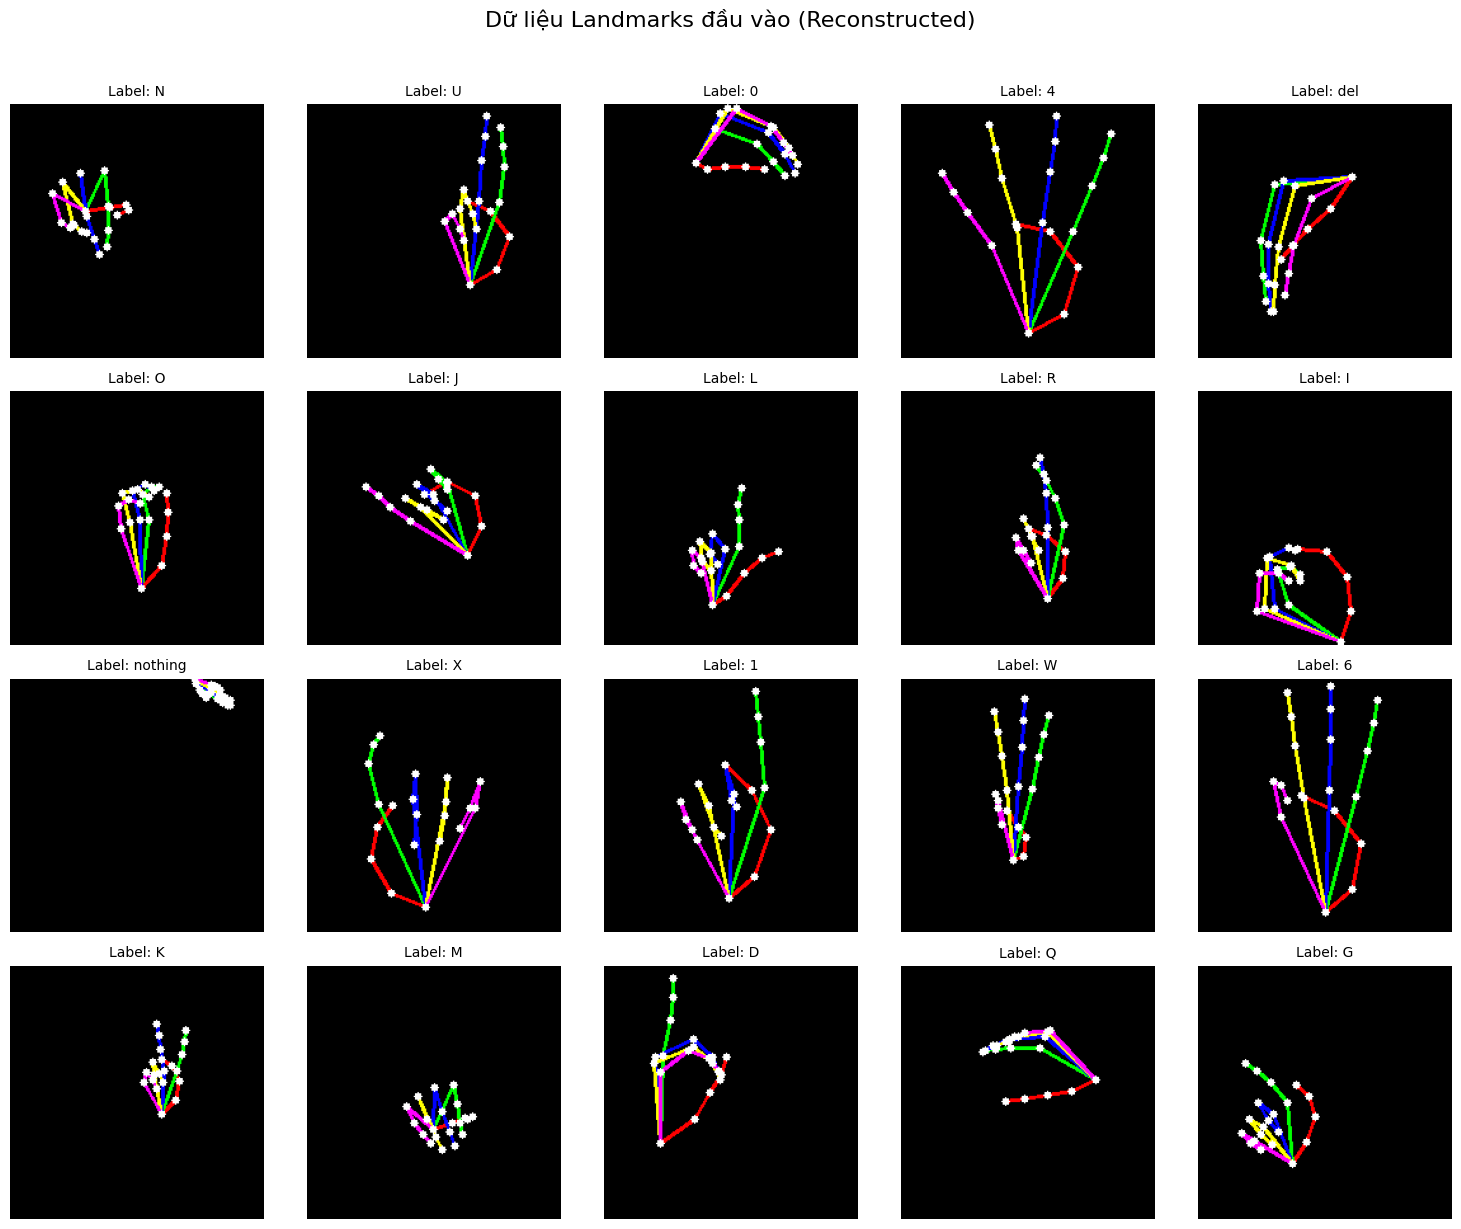

In [10]:
# --- CẬP NHẬT CELL 2.3: KIỂM TRA TRỰC QUAN (KHÔNG DÙNG MP.SOLUTIONS) ---
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt

if 'debug_samples' in globals():
    debug_samples = []

# Logic chọn ngẫu nhiên 20 ảnh từ các class khác nhau
if 'labels' in globals() and len(labels) > 0:
    unique_labels = list(set(labels))
    selected_indices = []

    random.shuffle(unique_labels)
    
    # Lấy mỗi class 1 ảnh cho đến khi đủ 20 ảnh
    for target_label in unique_labels[:20]:
        indices = [i for i, x in enumerate(labels) if x == target_label]
        if indices:
            selected_indices.append(random.choice(indices))

    print(f"Kiểm tra trực quan {len(selected_indices)} mẫu dữ liệu (Vẽ lại từ tọa độ đã xử lý):")

    rows = 4
    cols = 5
    plt.figure(figsize=(15, 12))

    # Định nghĩa các đốt ngón tay để nối dây (Dùng index của 21 điểm)
    # 0: Cổ tay
    finger_connections = {
        "thumb":  [(0, 1), (1, 2), (2, 3), (3, 4)],       # Ngón cái (Đỏ)
        "index":  [(0, 5), (5, 6), (6, 7), (7, 8)],       # Ngón trỏ (Xanh lá)
        "middle": [(0, 9), (9, 10), (10, 11), (11, 12)],  # Ngón giữa (Xanh dương)
        "ring":   [(0, 13), (13, 14), (14, 15), (15, 16)],# Ngón áp út (Vàng)
        "pinky":  [(0, 17), (17, 18), (18, 19), (19, 20)] # Ngón út (Tím)
    }
    
    # Định nghĩa màu sắc (R, G, B) cho matplotlib
    colors = {
        "thumb":  (255, 0, 0),
        "index":  (0, 255, 0),
        "middle": (0, 0, 255),
        "ring":   (255, 255, 0),
        "pinky":  (255, 0, 255)
    }

    for idx, data_idx in enumerate(selected_indices):
        if idx >= 20: break
        
        # Lấy vector tọa độ (42 điểm: x, y, x, y...)
        landmarks_vector = data[data_idx]
        label_name = labels[data_idx]
        
        # Tạo ảnh nền đen 200x200
        H, W = 200, 200
        blank_image = np.zeros((H, W, 3), dtype=np.uint8)
        
        # 1. Chuyển đổi vector thành danh sách tọa độ pixel (x, y)
        points = []
        for i in range(0, 42, 2):
            px = int(landmarks_vector[i] * W)
            py = int(landmarks_vector[i+1] * H)
            points.append((px, py))
            
        # 2. Vẽ các đường nối (Xương tay)
        for finger, connections in finger_connections.items():
            col = colors[finger]
            for i_start, i_end in connections:
                if i_start < len(points) and i_end < len(points):
                    cv2.line(blank_image, points[i_start], points[i_end], col, 2)
        
        # 3. Vẽ các khớp (Points)
        for p in points:
            cv2.circle(blank_image, p, 3, (255, 255, 255), -1) # Chấm trắng

        # Hiển thị
        plt.subplot(rows, cols, idx + 1)
        plt.imshow(blank_image)
        plt.title(f"Label: {label_name}", fontsize=10)
        plt.axis('off')

    plt.suptitle("Dữ liệu Landmarks đầu vào (Reconstructed)", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()

else:
    print("Chưa có dữ liệu 'labels'. Hãy chạy Cell 2.2 trước!")

## 2.4. Thống kê dữ liệu

Kiểm tra độ cân bằng của tập dữ liệu.

Kích thước dữ liệu đầu vào: (182715, 42)


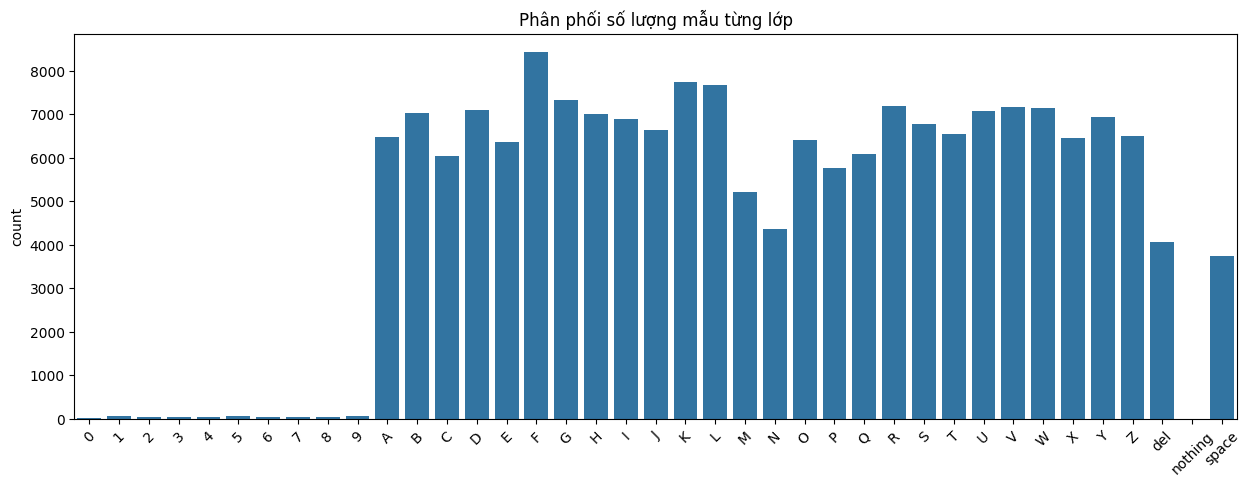

In [11]:
# Convert sang Numpy & DataFrame
data_np = np.asarray(data)
labels_np = np.asarray(labels)

print(f"Kích thước dữ liệu đầu vào: {data_np.shape}") # (Samples, 42)

plt.figure(figsize=(15, 5))
sns.countplot(x=labels, order=sorted(list(set(labels))))
plt.title('Phân phối số lượng mẫu từng lớp')
plt.xticks(rotation=45)
plt.show()

## 2.7. Lưu dữ liệu

In [12]:
import os

# Đặt tên file mới
PROCESSED_DATA_PATH = 'new_data.pickle'

if not SKIP_PROCESSING:
    print("Đang lưu file dữ liệu...")
    
    # Tạo dictionary dữ liệu
    data_to_save = {'data': data, 'labels': labels}
    
    # Lưu file
    with open(PROCESSED_DATA_PATH, 'wb') as f:
        pickle.dump(data_to_save, f)
    
    # --- KIỂM TRA THÔNG TIN FILE ---
    # 1. Kiểm tra dung lượng file
    file_size_bytes = os.path.getsize(PROCESSED_DATA_PATH)
    file_size_mb = file_size_bytes / (1024 * 1024) # Đổi sang MB
    
    print(f"Đã lưu thành công: '{PROCESSED_DATA_PATH}'")
    print(f"Dung lượng file: {file_size_mb:.2f} MB")
    
    # 2. Kiểm tra cấu trúc dữ liệu bên trong
    print("\n--- CHI TIẾT DỮ LIỆU ---")
    print(f"Các trường (Keys): {list(data_to_save.keys())}")
    print(f"'data' (Vectors): {len(data_to_save['data'])} mẫu (Đơn vị: List các vector 42 chiều)")
    print(f"'labels' (Nhãn):  {len(data_to_save['labels'])} nhãn (Đơn vị: String tên folder)")
    
    # Kiểm tra nhanh mẫu đầu tiên để đảm bảo đúng format
    if len(data) > 0:
        print(f"Ví dụ mẫu đầu tiên (Length): {len(data[0])} features")

else:
    print(f"Không cần lưu (Dữ liệu đã được load từ {PROCESSED_DATA_PATH})")

Đang lưu file dữ liệu...
Đã lưu thành công: 'new_data.pickle'
Dung lượng file: 67.44 MB

--- CHI TIẾT DỮ LIỆU ---
Các trường (Keys): ['data', 'labels']
'data' (Vectors): 182715 mẫu (Đơn vị: List các vector 42 chiều)
'labels' (Nhãn):  182715 nhãn (Đơn vị: String tên folder)
Ví dụ mẫu đầu tiên (Length): 42 features


# 3. Train Model

## 3.1. Giải thích tham số huấn luyện

Chúng ta sử dụng mạng nơ-ron nhân tạo (ANN) với các cấu hình sau:

    Epochs = 100: Số vòng lặp huấn luyện tối đa. Kết hợp với Early Stopping để dừng sớm nếu không học thêm được.

    Batch Size = 32: Số lượng mẫu được cập nhật trọng số một lần. Size nhỏ giúp mô hình thoát khỏi điểm tối ưu cục bộ tốt hơn.

    Dropout (0.3): Kỹ thuật Regularization, tắt ngẫu nhiên 30% nơ-ron trong quá trình train để ép mạng học các đặc trưng tổng quát, tránh học vẹt (Overfitting).

    Activation 'ReLU': Hàm kích hoạt phi tuyến tính chuẩn cho các lớp ẩn.

## 3.2. Chuẩn bị dữ liệu (Encoding & Splitting)

In [13]:
# Đường dẫn file dữ liệu đã xử lý (Phải khớp với Mục 2.7)
# PROCESSED_DATA_PATH = 'new_data.pickle'

print(f"Đang tải dữ liệu từ: {PROCESSED_DATA_PATH}...")

if os.path.exists(PROCESSED_DATA_PATH):
    # Load dữ liệu
    with open(PROCESSED_DATA_PATH, 'rb') as f:
        data_dict = pickle.load(f)
        
    # Chuyển sang Numpy array
    data_np = np.asarray(data_dict['data'])
    labels_raw = np.asarray(data_dict['labels'])
    
    print(f"Tải thành công! Kích thước dữ liệu: {data_np.shape}")

    # Mã hóa nhãn (String -> Integer)
    le = LabelEncoder()
    labels_encoded = le.fit_transform(labels_raw)
    num_classes = len(le.classes_)
    print(f"Số lượng lớp (Classes): {num_classes}")

    # Chia tập Train/Test (80/20)
    x_train, x_test, y_train, y_test = train_test_split(
        data_np, labels_encoded, 
        test_size=0.2, 
        shuffle=True, 
        stratify=labels_encoded, 
        random_state=42
    )

    print(f"- Train set: {x_train.shape}")
    print(f"- Test set: {x_test.shape}")

else:
    print(f"LỖI: Không tìm thấy file '{PROCESSED_DATA_PATH}'. Vui lòng chạy lại Mục 2 với SKIP_PROCESSING = False.")

Đang tải dữ liệu từ: new_data.pickle...
Tải thành công! Kích thước dữ liệu: (182715, 42)
Số lượng lớp (Classes): 39
- Train set: (146172, 42)
- Test set: (36543, 42)


## 3.3. Xây dựng & Huấn luyện mô hình

In [14]:
# Xây dựng mạng ANN
model = Sequential([
    # Input Layer (42 features) -> Hidden Layer 1
    Dense(128, input_shape=(42,), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    # Hidden Layer 2
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    # Output Layer (Softmax cho bài toán phân loại nhiều lớp)
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

I0000 00:00:1770374328.242894      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1770374328.248891      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 39)             │         2,535 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,063 (66.65 KB)

 Trainable params: 16,679 (65.15 KB)

 Non-trainable params: 384 (1.50 KB)

In [15]:
# Cấu hình Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Bắt đầu huấn luyện
history = model.fit(
    x_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(x_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


I0000 00:00:1770374332.538660     108 service.cc:152] XLA service 0x7f723c0073c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770374332.538693     108 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1770374332.538696     108 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1770374333.036035     108 cuda_dnn.cc:529] Loaded cuDNN version 91002


  71/4568 ━━━━━━━━━━━━━━━━━━━━ 9s 2ms/step - accuracy: 0.0620 - loss: 3.9536 

I0000 00:00:1770374335.202363     108 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


4568/4568 ━━━━━━━━━━━━━━━━━━━━ 20s 3ms/step - accuracy: 0.6674 - loss: 1.2357 - val_accuracy: 0.8433 - val_loss: 0.5420
Epoch 2/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8306 - loss: 0.5883 - val_accuracy: 0.8919 - val_loss: 0.3845
Epoch 3/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8384 - loss: 0.5524 - val_accuracy: 0.9093 - val_loss: 0.3365
Epoch 4/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8435 - loss: 0.5434 - val_accuracy: 0.9274 - val_loss: 0.2788
Epoch 5/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8473 - loss: 0.5304 - val_accuracy: 0.9322 - val_loss: 0.2656
Epoch 6/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8528 - loss: 0.5135 - val_accuracy: 0.8934 - val_loss: 0.3400
Epoch 7/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8593 - loss: 0.4946 - val_accuracy: 0.9250 - val_loss: 0.2761
Epoch 8/100
4568/4568 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.8609 - loss: 0.484

## 3.4. Đánh giá & Lưu mô hình (Dynamic Saving)

Tên file mô hình sẽ tự động bao gồm: Độ chính xác (Acc) + Ngày giờ huấn luyện.

In [16]:
from sklearn.metrics import classification_report, top_k_accuracy_score
import time

# --- 3.4. DANH GIA CHI TIET MO HINH (DETAILED EVALUATION) ---

print("=== 1. TONG QUAN HIEU SUAT (PERFORMANCE OVERVIEW) ===")

# 1.1. Danh gia tren tap Test (Final Evaluation)
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy:  {test_acc * 100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")

# 1.2. Danh gia tren tap Train (de so sanh Overfitting)
train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
print(f"Train Accuracy: {train_acc * 100:.2f}%")

# 1.3. Kiem tra Overfitting / Underfitting
print("\n=== 2. PHAN TICH OVERFITTING/UNDERFITTING ===")
acc_gap = train_acc - test_acc

print(f"Chenh lech (Train - Test): {acc_gap * 100:.2f}%")

if train_acc < 0.70:
    print("KET LUAN: Underfitting (Mo hinh chua hoc duoc dac trung).")
    print("GIAI PHAP: Tang do phuc tap mo hinh (them layer/neuron), train lau hon.")
elif acc_gap > 0.10: # Chenh lech > 10%
    print("KET LUAN: Overfitting nang (Hoc vet du lieu Train).")
    print("GIAI PHAP: Tang Dropout, giam do phuc tap mo hinh, them du lieu.")
elif acc_gap > 0.05: # Chenh lech > 5%
    print("KET LUAN: Co dau hieu Overfitting nhe.")
    print("GIAI PHAP: Chap nhan duoc, nhung co the tang nhe Dropout.")
else:
    print("KET LUAN: Mo hinh tot (Good Fit), on dinh giua Train va Test.")

# 1.4. Do toc do du doan (Inference Speed)
print("\n=== 3. TOC DO DU DOAN (INFERENCE SPEED) ===")
start_time = time.time()
y_pred_probs = model.predict(x_test, verbose=0)
end_time = time.time()

total_time = end_time - start_time
avg_time_per_sample = (total_time / len(x_test)) * 1000 # doi sang ms

print(f"Tong thoi gian du doan {len(x_test)} mau: {total_time:.4f} giay")
print(f"Trung binh moi mau: {avg_time_per_sample:.4f} ms")

# 1.5. Top-k Accuracy (Do chinh xac trong Top 3 va Top 5)
# (Huu ich voi ASL vi co nhieu ky tu gan giong nhau nhu M, N, S)
print("\n=== 4. TOP-K ACCURACY ===")
# Lay du doan class
y_pred = np.argmax(y_pred_probs, axis=1)

top3_acc = top_k_accuracy_score(y_test, y_pred_probs, k=3)
top5_acc = top_k_accuracy_score(y_test, y_pred_probs, k=5)

print(f"Top-3 Accuracy: {top3_acc * 100:.2f}% (Xac suat dap an dung nam trong 3 du doan cao nhat)")
print(f"Top-5 Accuracy: {top5_acc * 100:.2f}% (Xac suat dap an dung nam trong 5 du doan cao nhat)")

# 1.6. Bao cao chi tiet tung lop
print("\n=== 5. BAO CAO CHI TIET (CLASSIFICATION REPORT) ===")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# --- DYNAMIC SAVING ---
print("\n=== 6. LUU MO HINH (SAVING) ===")
current_time = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"model_acc{test_acc*100:.2f}_{current_time}.keras"

model.save(model_filename)
print(f"Da luu model: {model_filename}")

# Luu Label Encoder
with open('label_encoder.pickle', 'wb') as f:
    pickle.dump(le, f)
print("Da luu Label Encoder: label_encoder.pickle")

=== 1. TONG QUAN HIEU SUAT (PERFORMANCE OVERVIEW) ===
Test Accuracy:  94.42%
Test Loss:      0.2118
Train Accuracy: 94.68%

=== 2. PHAN TICH OVERFITTING/UNDERFITTING ===
Chenh lech (Train - Test): 0.25%
KET LUAN: Mo hinh tot (Good Fit), on dinh giua Train va Test.

=== 3. TOC DO DU DOAN (INFERENCE SPEED) ===
Tong thoi gian du doan 36543 mau: 2.5271 giay
Trung binh moi mau: 0.0692 ms

=== 4. TOP-K ACCURACY ===
Top-3 Accuracy: 98.39% (Xac suat dap an dung nam trong 3 du doan cao nhat)
Top-5 Accuracy: 98.98% (Xac suat dap an dung nam trong 5 du doan cao nhat)

=== 5. BAO CAO CHI TIET (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.33      0.09      0.14        11
           2       0.00      0.00      0.00         9
           3       1.00      1.00      1.00        11
           4       0.00      0.00      0.00        11
           5       1.00      0.83      0.91        12
     

## 3.5. Biểu đồ Learning Curve & Confusion Matrix

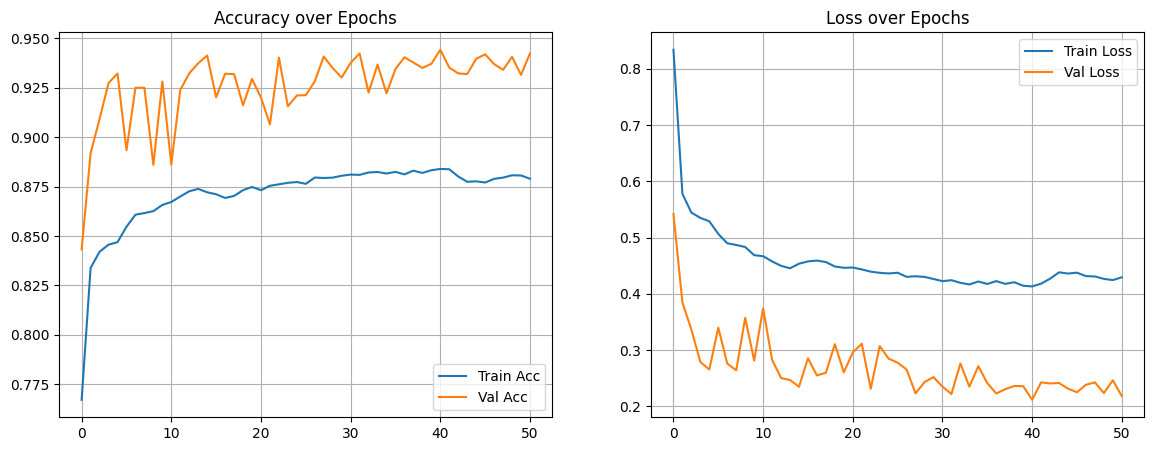

1142/1142 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


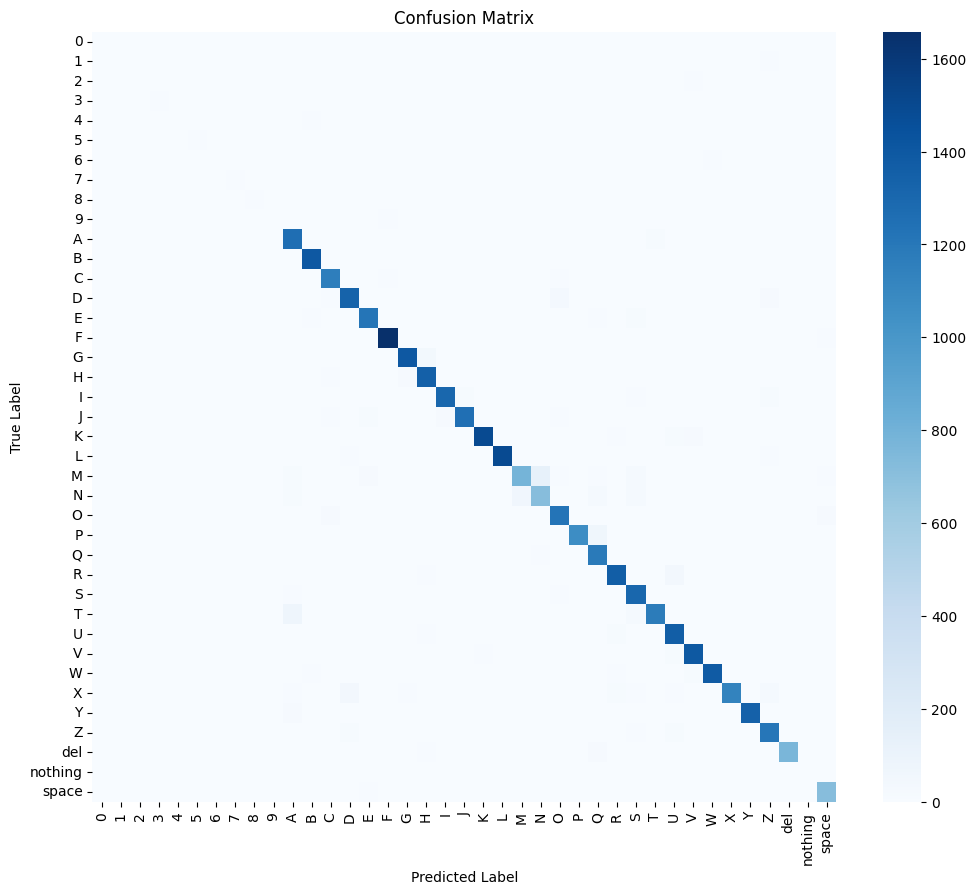

In [17]:
# Vẽ Learning Curve
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()
plt.grid(True)
plt.show()

# Vẽ Confusion Matrix
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Test Model (Inference)

4.1. Giải thích tham số Test

Khi chạy thực tế trên tập Test (dữ liệu chưa từng thấy), ta cần điều chỉnh:

    min_hand_detection_confidence = 0.3: Dữ liệu thực tế thường nhiễu hơn training. Hạ ngưỡng này xuống 0.3 giúp tăng khả năng bắt được tay (Recall), tránh bỏ sót.

    c_score (Confidence Score): Hiển thị độ tự tin của mô hình với dự đoán đó (ví dụ: Chắc chắn 99% đây là chữ A).

## 4.2. Chạy Dự đoán (Inference Loop)

Đoạn code này thực hiện đầy đủ quy trình: Đọc ảnh -> Detect Landmarks -> Chuẩn hóa bounding box -> Predict -> Visualize kết quả.

W0000 00:00:1770374974.754833    1463 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1770374974.775639    1463 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Bắt đầu kiểm thử và Visualize trên tập: /kaggle/working/ASL_TOTAL_TEST


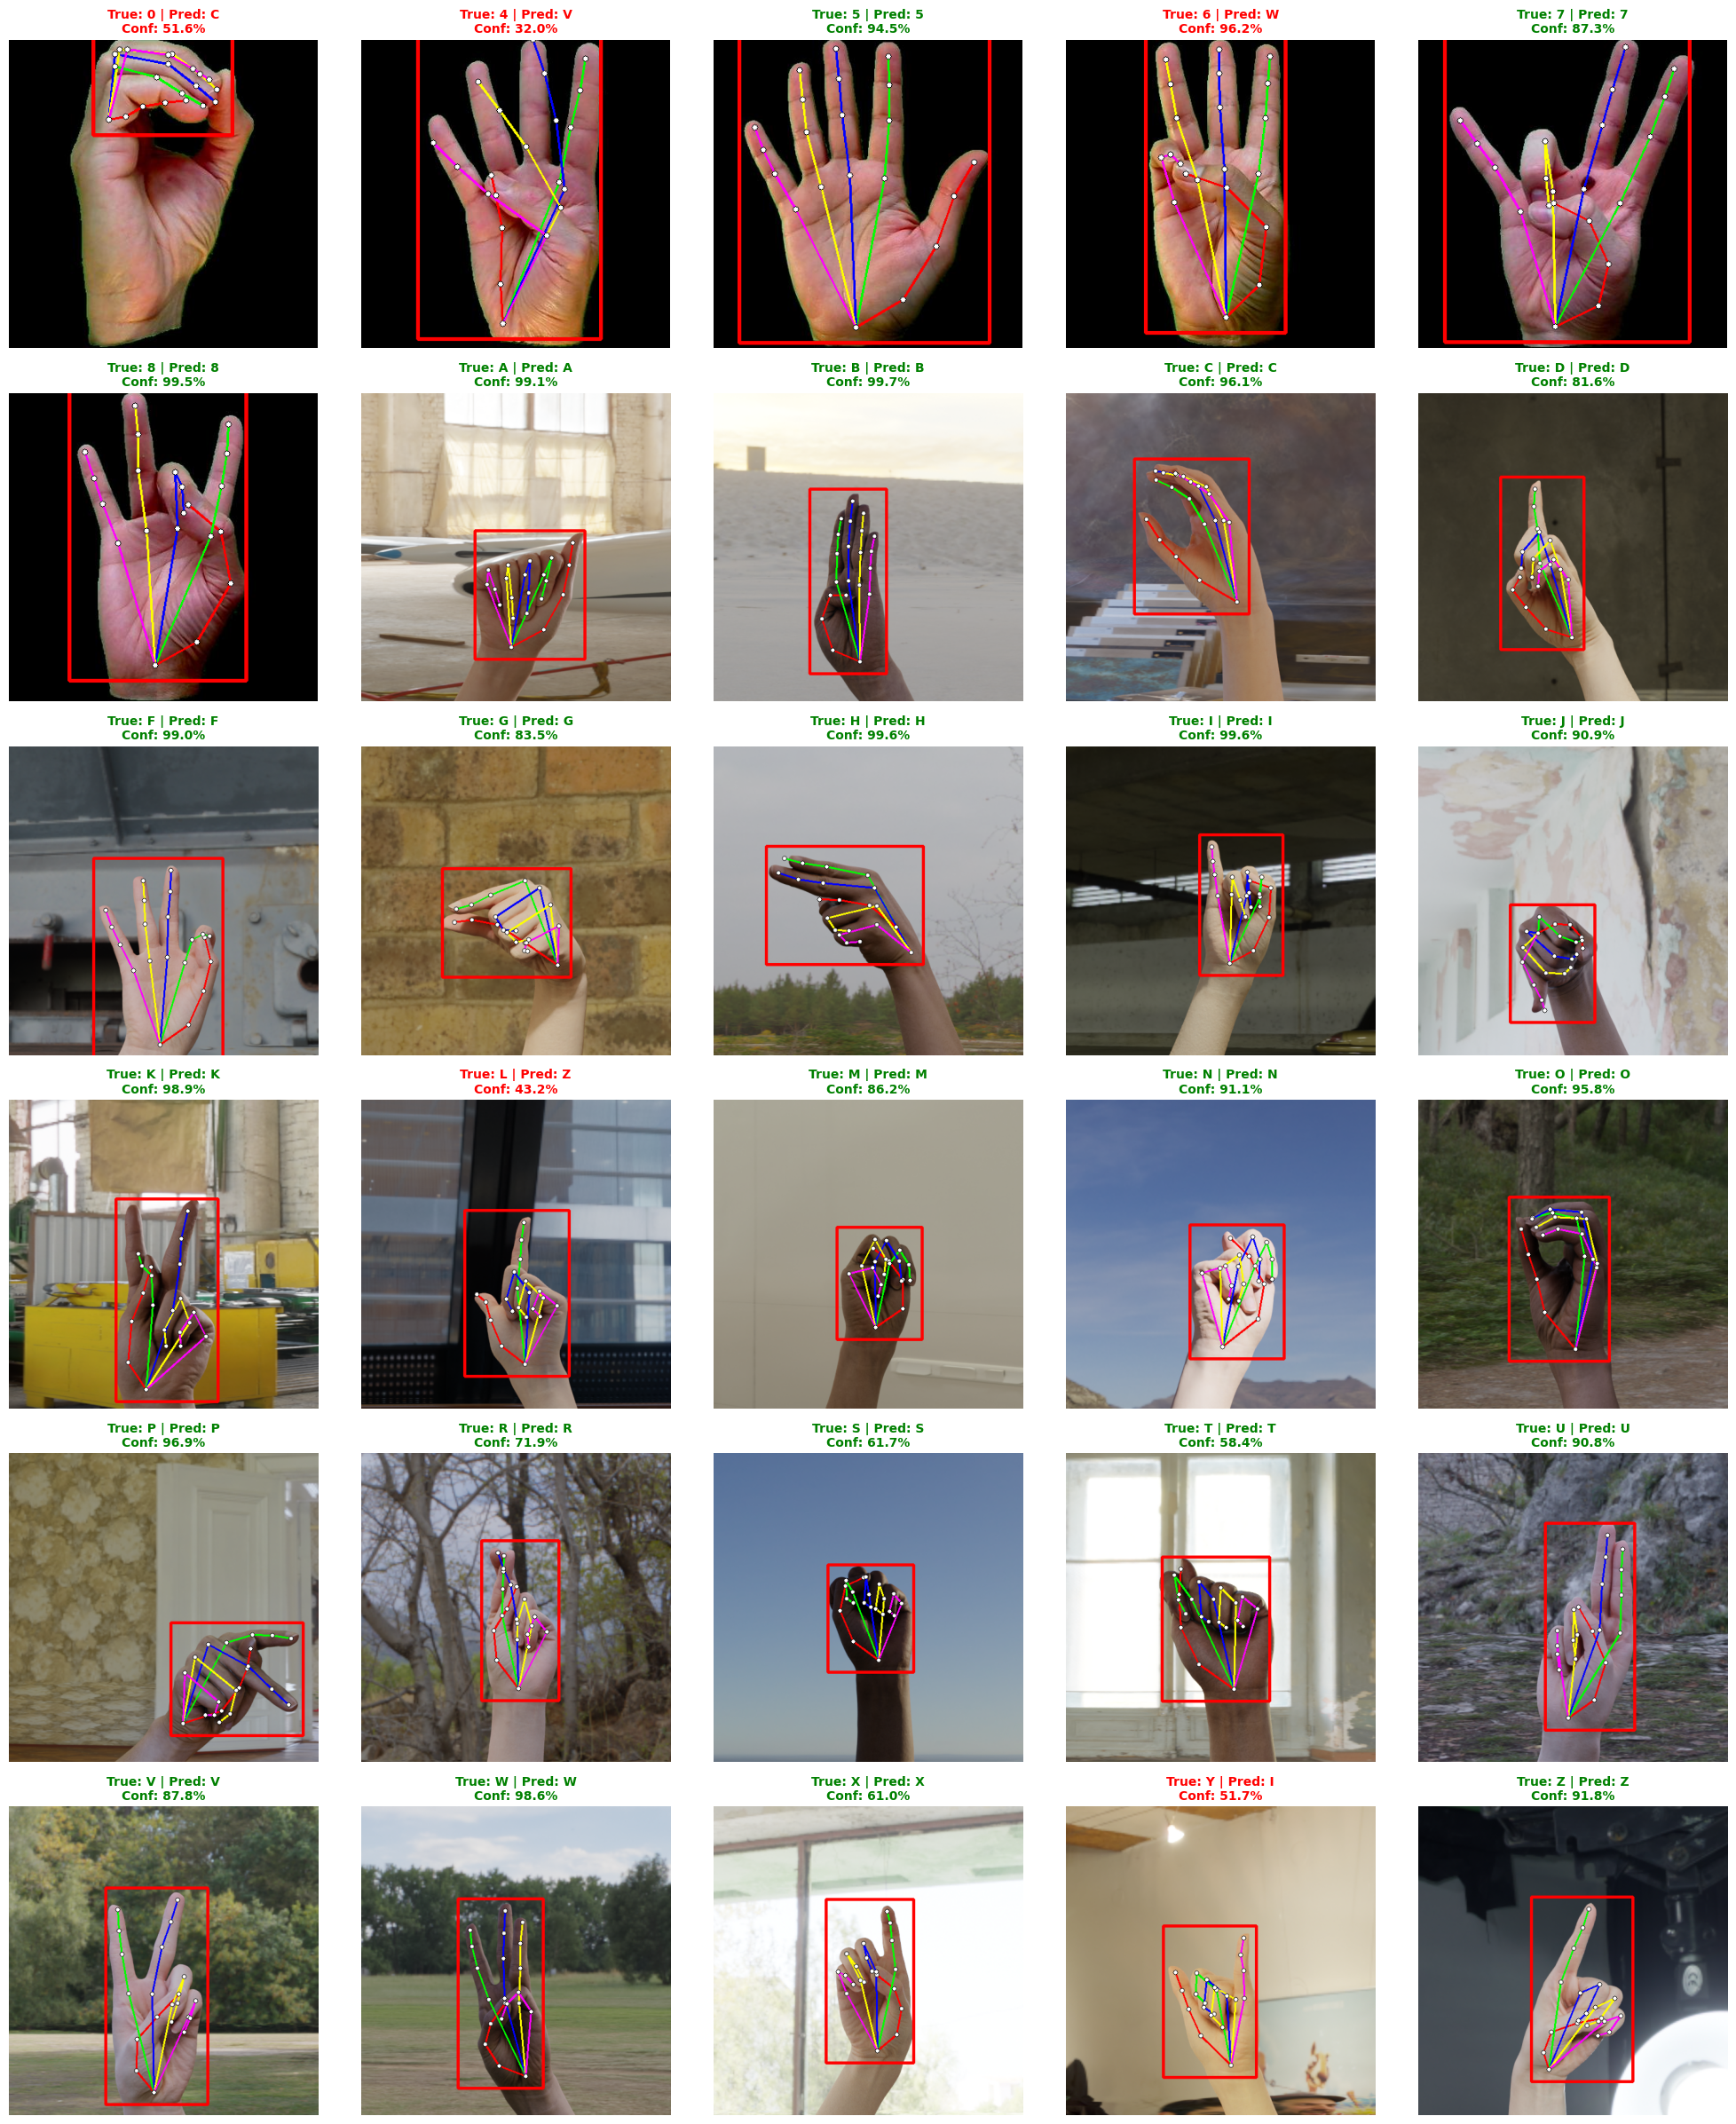

In [18]:
# --- CẬP NHẬT ĐƯỜNG DẪN TEST MỚI ---
TEST_DIR = '/kaggle/working/ASL_TOTAL_TEST'

# Load Model & Encoder
model = load_model(model_filename)
with open('label_encoder.pickle', 'rb') as f:
    le = pickle.load(f)

# Cấu hình Detector
base_options = python.BaseOptions(model_asset_path='hand_landmarker.task')
options = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=1,
    min_hand_detection_confidence=0.3
)
detector = vision.HandLandmarker.create_from_options(options)

print(f"Bắt đầu kiểm thử và Visualize trên tập: {TEST_DIR}")

total_test_samples = 0
correct_predictions = 0
results_per_class = {} 

test_classes = sorted(os.listdir(TEST_DIR))

# Chuẩn bị plot để hiển thị 1 ảnh đại diện cho mỗi class
# Tính toán số dòng cần thiết (mỗi dòng 5 ảnh)
num_classes_viz = len(test_classes)
cols = 5
rows = (num_classes_viz // cols) + (1 if num_classes_viz % cols > 0 else 0)
plt.figure(figsize=(20, 4 * rows))
viz_index = 1

for cls in test_classes:
    cls_path = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_path): continue
    
    img_files = os.listdir(cls_path)
    if len(img_files) == 0: continue

    results_per_class[cls] = [0, 0]
    
    # Chọn ngẫu nhiên 1 ảnh để visualize cho class này
    random_viz_img = random.choice(img_files)
    viz_img_processed = None
    viz_pred_char = ""
    viz_c_score = 0.0
    
    print(f"Testing class '{cls}'...", end="\r")
    
    for img_name in img_files:
        img_path = os.path.join(cls_path, img_name)
        frame = cv2.imread(img_path)
        if frame is None: continue
        
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        detection_result = detector.detect(mp_image)

        if detection_result.hand_landmarks:
            hand_landmarks = detection_result.hand_landmarks[0]
            data_aux = []
            x_coords = []
            y_coords = []
            
            for lm in hand_landmarks:
                data_aux.extend([lm.x, lm.y])
                x_coords.append(lm.x)
                y_coords.append(lm.y)

            if len(data_aux) == 42:
                # Predict
                pred_prob = model.predict([np.asarray(data_aux).reshape(1, -1)], verbose=0)
                pred_idx = np.argmax(pred_prob)
                pred_char = le.inverse_transform([pred_idx])[0]
                c_score = np.max(pred_prob)
                
                # Thống kê
                results_per_class[cls][1] += 1
                total_test_samples += 1
                
                if pred_char.upper() == cls.upper():
                    results_per_class[cls][0] += 1
                    correct_predictions += 1
                
                # Xử lý ảnh Visualize (nếu là ảnh được chọn)
                if img_name == random_viz_img:
                    viz_pred_char = pred_char
                    viz_c_score = c_score
                    
                    # 1. Vẽ Landmarks
                    annotated_rgb = draw_landmarks_on_image_new(frame_rgb, detection_result)
                    
                    # 2. Vẽ Bounding Box
                    H, W, _ = frame.shape
                    x1 = int(min(x_coords) * W) - 20
                    y1 = int(min(y_coords) * H) - 20
                    x2 = int(max(x_coords) * W) + 20
                    y2 = int(max(y_coords) * H) + 20
                    
                    # Vẽ lên ảnh RGB (vì plt dùng RGB)
                    cv2.rectangle(annotated_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3) # Đỏ trong RGB là (255,0,0)
                    viz_img_processed = annotated_rgb

    # Hiển thị ảnh đại diện cho Class vừa chạy xong
    if viz_img_processed is not None:
        plt.subplot(rows, cols, viz_index)
        plt.imshow(viz_img_processed)
        
        # Màu tiêu đề: Xanh nếu đúng, Đỏ nếu sai
        title_color = 'green' if viz_pred_char.upper() == cls.upper() else 'red'
        
        plt.title(f"True: {cls} | Pred: {viz_pred_char}\nConf: {viz_c_score:.1%}", 
                  color=title_color, fontsize=10, fontweight='bold')
        plt.axis('off')
        viz_index += 1

detector.close()
plt.tight_layout()
plt.show()

In [19]:
print("\n" + "="*40)
print("KẾT QUẢ KIỂM THỬ CHI TIẾT")
print("="*40)
if total_test_samples > 0:
    final_acc = correct_predictions / total_test_samples
    print(f"Độ chính xác trung bình: {final_acc * 100:.2f}%")
    print("-" * 40)
    print(f"{'CLASS':<10} | {'ACCURACY':<10} | {'SỐ LƯỢNG':<10}")
    print("-" * 40)
    for cls in results_per_class:
        correct, total = results_per_class[cls]
        if total > 0:
            acc_cls = (correct / total) * 100
            print(f"{cls:<10} | {acc_cls:<10.2f}% | {correct}/{total}")
else:
    print("Không có dữ liệu test hợp lệ.")


KẾT QUẢ KIỂM THỬ CHI TIẾT
Độ chính xác trung bình: 90.67%
----------------------------------------
CLASS      | ACCURACY   | SỐ LƯỢNG  
----------------------------------------
0          | 0.00      % | 0/9
1          | 11.11     % | 1/9
2          | 0.00      % | 0/10
3          | 93.75     % | 15/16
4          | 13.33     % | 2/15
5          | 87.50     % | 7/8
6          | 0.00      % | 0/10
7          | 81.82     % | 9/11
8          | 100.00    % | 12/12
9          | 0.00      % | 0/9
A          | 95.79     % | 91/95
B          | 100.00    % | 93/93
C          | 95.74     % | 90/94
D          | 94.12     % | 80/85
E          | 89.77     % | 79/88
F          | 98.90     % | 90/91
G          | 98.98     % | 97/98
H          | 98.99     % | 98/99
I          | 97.80     % | 89/91
J          | 96.84     % | 92/95
K          | 94.68     % | 89/94
L          | 91.30     % | 84/92
M          | 76.74     % | 66/86
N          | 85.26     % | 81/95
O          | 95.88     % | 93/97
P        